## Project Objective

This project analyzes COVID-19 global data to understand the spread,
impact, and trends of confirmed cases, deaths, and recoveries.

The goal is to explore patterns over time and across countries
using data analysis and visualization techniques.

In [1]:
# libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Loading the Dataset
CovidData = pd.read_csv("country_wise_latest.csv")

In [3]:
CovidData.head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,2.67,34981,2409,6.89,Europe
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,1.79,12428,2875,23.13,Western Pacific
9,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,3.91,19743,815,4.13,Europe


## Data Exploration:


In [5]:
CovidData.shape

(187, 15)

In [6]:
CovidData.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [111]:
CovidData.info() # (187 x 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [7]:
CovidData.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [60]:
CovidData.duplicated().sum() # no duplicates.

np.int64(0)

In [112]:
len(CovidData["Country/Region"].unique()) # all country names are unique

187

In [113]:
CovidData["Country/Region"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Greenland',
       'Grenada', 'Guatemala', 'Guinea', 'G

## Top Countries by Confirmed Cases

<Axes: xlabel='Confirmed', ylabel='Country/Region'>

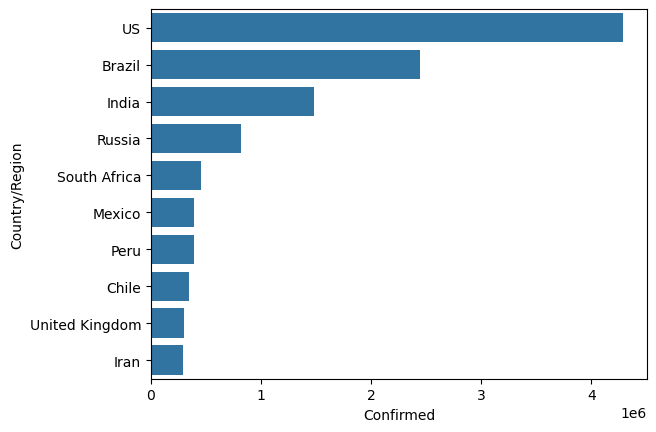

In [14]:
top_cases = CovidData.sort_values('Confirmed', ascending=False).head(10)

sns.barplot(x='Confirmed', y='Country/Region', data=top_cases)



In [58]:
#Top 2:
ToptwoCountries = CovidData.sort_values("Confirmed", ascending = False).head(2) # top 2 Countries on Confirmed.
ToptwoCountries

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
173,US,4290259,148011,1325804,2816444,56336,1076,27941,3.45,30.90,11.16,3834677,455582,11.88,Americas
23,Brazil,2442375,87618,1846641,508116,23284,614,33728,3.59,75.61,4.74,2118646,323729,15.28,Americas


<Axes: xlabel='Country/Region', ylabel='Confirmed'>

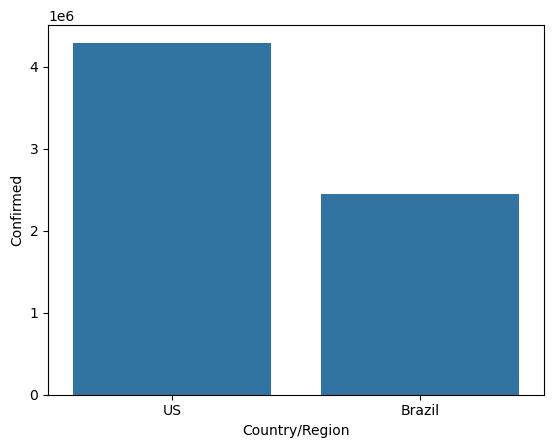

In [59]:
sns.barplot(x = "Country/Region", y = "Confirmed", data = ToptwoCountries)

## Death Analysis

<Axes: xlabel='Deaths', ylabel='Country/Region'>

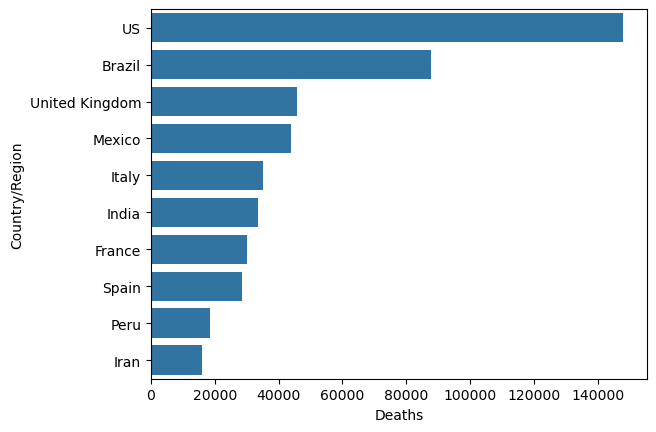

In [15]:
top_deaths = CovidData.sort_values('Deaths', ascending=False).head(10)

sns.barplot(x='Deaths', y='Country/Region', data=top_deaths)



## Recovery Analysis

<Axes: xlabel='Recovered', ylabel='Country/Region'>

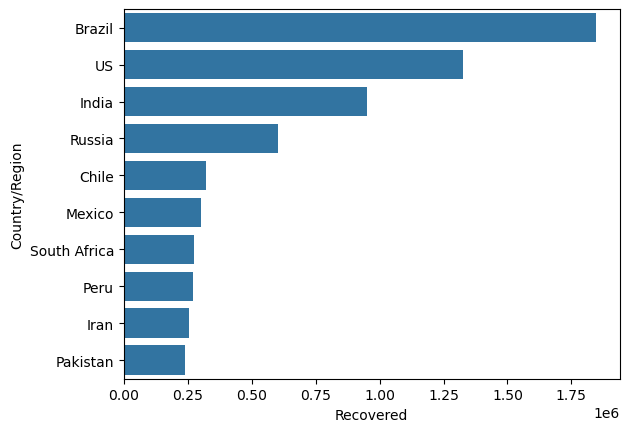

In [16]:
top_recovered = CovidData.sort_values('Recovered', ascending=False).head(10)

sns.barplot(x='Recovered', y='Country/Region', data=top_recovered)


## Mortality Rate:

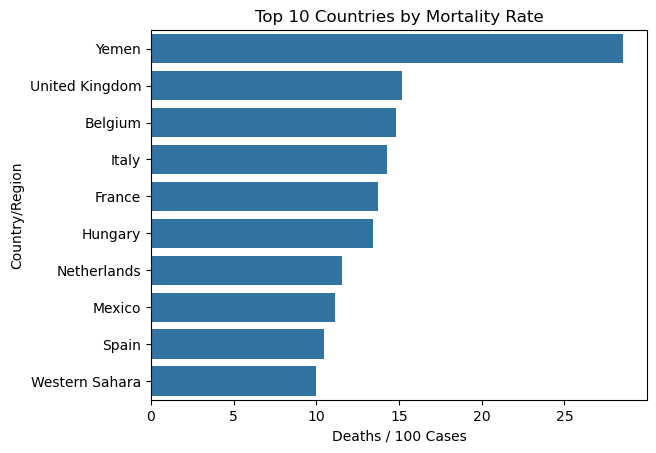

In [20]:
top_mortality = CovidData.sort_values('Deaths / 100 Cases', ascending=False).head(10)

sns.barplot(x='Deaths / 100 Cases' , y='Country/Region', data = top_mortality)

plt.title("Top 10 Countries by Mortality Rate") # title.
plt.show()


## Weekly Growth Analysis

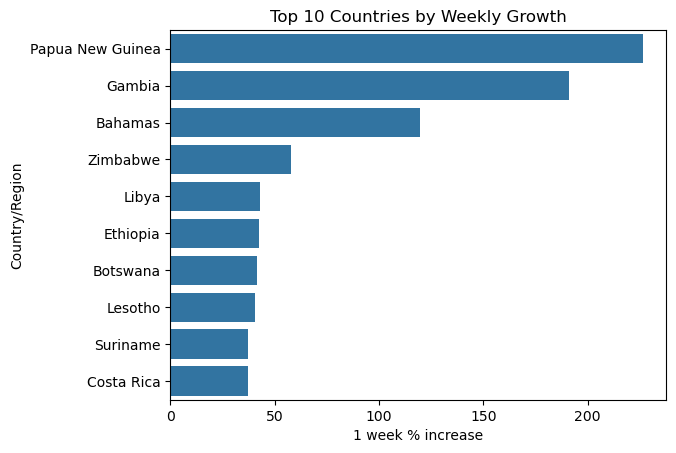

In [22]:
weekly_growth = CovidData.sort_values('1 week % increase', ascending=False).head(10) 

sns.barplot(x = '1 week % increase', y = 'Country/Region', data = weekly_growth )

plt.title("Top 10 Countries by Weekly Growth")
plt.show()


## Correlation:

<function matplotlib.pyplot.show(close=None, block=None)>

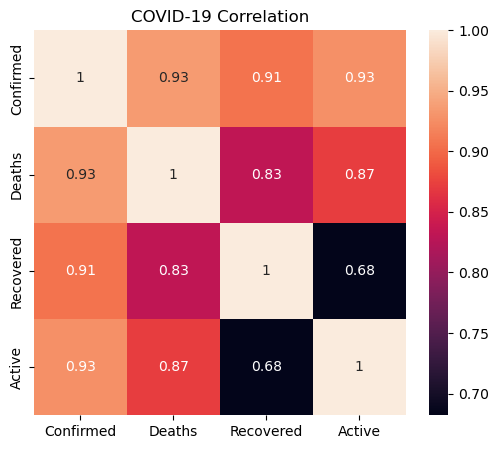

In [67]:
# Correlation between COVID-19 columns

plt.figure(figsize=(6,5))
sns.heatmap(CovidData[['Confirmed','Deaths','Recovered','Active']].corr(), annot=True)

plt.title("COVID-19 Correlation")
plt.show



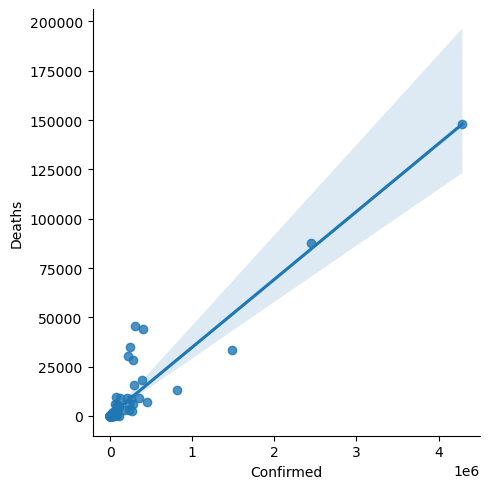

In [27]:
# Relationship Between Confirmed Cases and Deaths
sns.lmplot(x = "Confirmed", y = "Deaths", data = CovidData)

#The upward trend indicates that countries with higher confirmed cases generally experienced higher death counts and highlighting a strong
# positive correlation between infections and fatalities.

In [30]:
#1. find recovery %age for Afghanistan,Algeria,Andorra | "Afghanistan","Algeria","Andorra"

In [33]:
CovidData.loc[CovidData["Country/Region"].isin(["Afghanistan","Algeria","Andorra"])]

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe


In [34]:
filterData = CovidData[["Country/Region","Confirmed","Recovered"]].loc[CovidData["Country/Region"].isin(["Afghanistan","Algeria","Andorra"])]

In [35]:
filterData

,Country/Region,Confirmed,Recovered
0,Afghanistan,36263,25198
2,Algeria,27973,18837
3,Andorra,907,803


In [36]:
filterData["Recovered%"] = filterData["Recovered"]/filterData["Confirmed"] * 100

In [37]:
filterData

,Country/Region,Confirmed,Recovered,Recovered%
0,Afghanistan,36263,25198,69.486805
2,Algeria,27973,18837,67.339935
3,Andorra,907,803,88.533627


<Axes: xlabel='Country/Region', ylabel='Recovered%'>

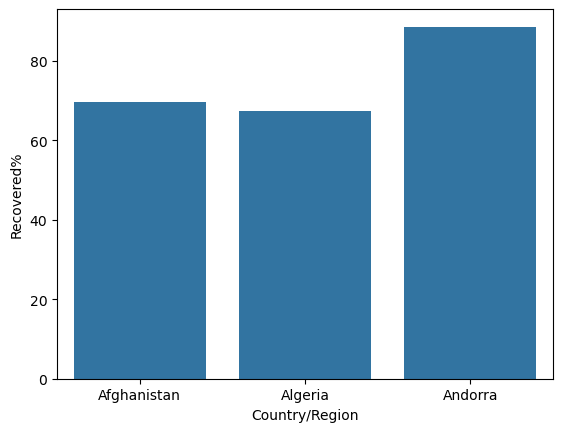

In [39]:
sns.barplot(x = "Country/Region", y = "Recovered%", data = filterData )

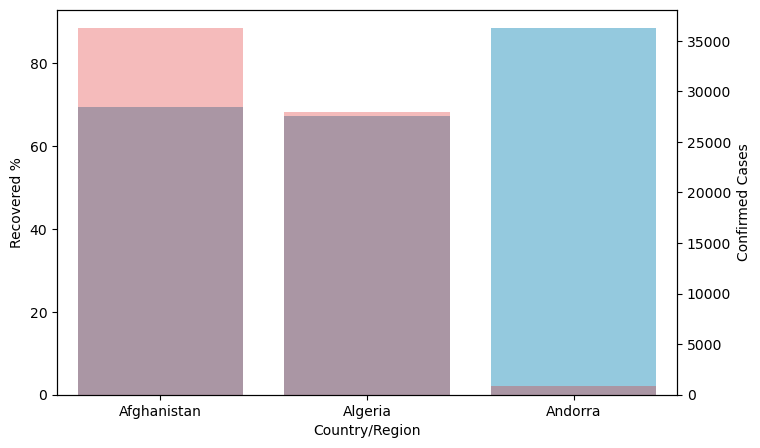

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(8,5))

# Barplot for Recovered%
sns.barplot(x="Country/Region", y="Recovered%", data=filterData, ax=ax1, color='skyblue')
ax1.set_ylabel("Recovered %")

# Second axis for Confirmed
ax2 = ax1.twinx()  # shares x-axis
sns.barplot(x="Country/Region", y="Confirmed", data=filterData, ax=ax2, alpha=0.3, color='red')
ax2.set_ylabel("Confirmed Cases")

plt.show()

In [41]:
CovidData[["WHO Region"]]

,WHO Region
0,Eastern Mediterranean
1,Europe
2,Africa
3,Europe
4,Africa
...,...
182,Eastern Mediterranean
183,Africa
184,Eastern Mediterranean
185,Africa


In [42]:
len(CovidData["WHO Region"].unique()) # total 6 unique Reqions.

6

In [128]:
CovidData[["WHO Region","Confirmed","Recovered","Deaths"]]

,WHO Region,Confirmed,Recovered,Deaths
0,Eastern Mediterranean,36263,25198,1269
1,Europe,4880,2745,144
2,Africa,27973,18837,1163
3,Europe,907,803,52
4,Africa,950,242,41
...,...,...,...,...
182,Eastern Mediterranean,10621,3752,78
183,Africa,10,8,1
184,Eastern Mediterranean,1691,833,483
185,Africa,4552,2815,140


In [43]:
# Regional Summary Analysis Based on WHO Regions

In [46]:
# Grouping data by WHO Region and summing key metrics:- 
SummarizedData = CovidData.groupby("WHO Region")[["Confirmed", "Recovered", "Deaths"]].sum()

# Calculating recovery and death percentages:-
SummarizedData["RecoveryRate"] = (SummarizedData["Recovered"] / SummarizedData["Confirmed"]) * 100

SummarizedData["DeathRate"] = (SummarizedData["Deaths"] / SummarizedData["Confirmed"]) * 100
SummarizedData

,Confirmed,Recovered,Deaths,RecoveryRate,DeathRate
WHO Region,,,,,
Africa,723207,440645,12223,60.929305,1.690111
Americas,8839286,4468616,342732,50.554038,3.877372
Eastern Mediterranean,1490744,1201400,38339,80.590631,2.571803
Europe,3299523,1993723,211144,60.424583,6.399228
South-East Asia,1835297,1156933,41349,63.037917,2.252987
Western Pacific,292428,206770,8249,70.708003,2.820865


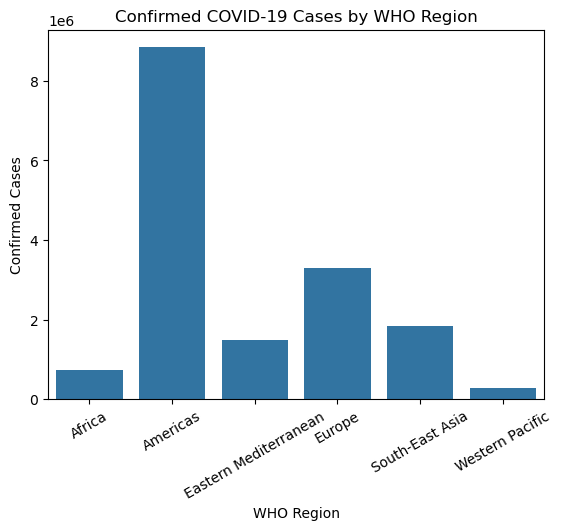

In [55]:
# Comparing COVID-19 cases across WHO regions

region_data = SummarizedData

sns.barplot(x="WHO Region", y="Confirmed", data=region_data)

plt.title("Confirmed COVID-19 Cases by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=30)
plt.show()

# Observation:
# Some WHO regions have much higher confirmed cases than others, showing that COVID-19 impact varies across regions.


# Key Insights

- The United States, Brazil, and India are the most affected countries.
- Higher confirmed cases are strongly associated with higher deaths.
- Some countries show high recovery rates despite large case numbers.
- Weekly growth varies significantly across regions.